<a href="https://colab.research.google.com/github/praveenkakinadakiet-alt/PHEONIX-/blob/main/IMAGE_TRANSFORMATIONS_DECOMPOSER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMAGE TRANSFORMATION DECOMPOSER (B10)

Input matrix A:
 [[ 2. -1.]
 [ 1.  2.]]

1. CHARACTERISTIC EQUATION
det(A - lambda*I) = 5.0*(0.2*lambda**2 - 0.8*lambda + 1.0)
Solve the equation = 5.0*(0.2*lambda**2 - 0.8*lambda + 1.0) = 0

2. EIGENVALUES AND EIGENVECTORS

Eigenvalue 1: (2+1j)
Eigenvector 1: [0.7071+0.j     0.    -0.7071j]
Verification ||Av - lambda*v|| = 0.00e+00
Eigenpair verified successfully.

Eigenvalue 2: (2-1j)
Eigenvector 2: [0.7071-0.j     0.    +0.7071j]
Verification ||Av - lambda*v|| = 0.00e+00
Eigenpair verified successfully.

3. EIGEN-DECOMPOSITION
A = P D P^(-1)

P =
 [[0.7071+0.j     0.7071-0.j    ]
 [0.    -0.7071j 0.    +0.7071j]]

D =
 [[2.+1.j 0.+0.j]
 [0.+0.j 2.-1.j]]

Reconstruction error = 3.208616525162835e-17

4. POLAR DECOMPOSITION
A = R U

Orthogonal factor R:
 [[ 0.8944 -0.4472]
 [ 0.4472  0.8944]]

Stretching factor U:
 [[2.2361 0.    ]
 [0.     2.2361]]

Orthogonal factor type: Rotation
Singular values: [2.2361 2.2361]
det(A) = 5.000000000000001
Pola

## Numerical Results

,Eigenvalue,Eigenvector,Magnitude
0,(2+1j),[0.7071+0.j 0. -0.7071j],2.236068
1,(2-1j),[0.7071-0.j 0. +0.7071j],2.236068


### Input Transformation Matrix

,Column 1,Column 2
Row 1,2.0,-1.0
Row 2,1.0,2.0


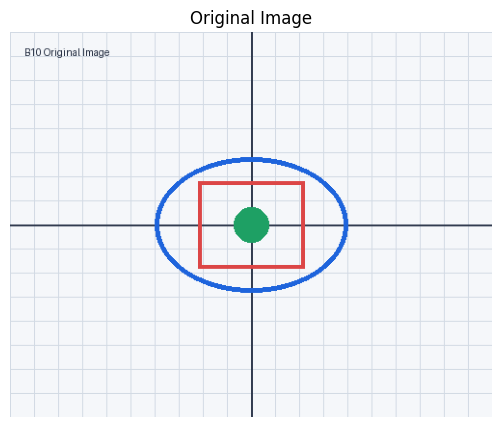

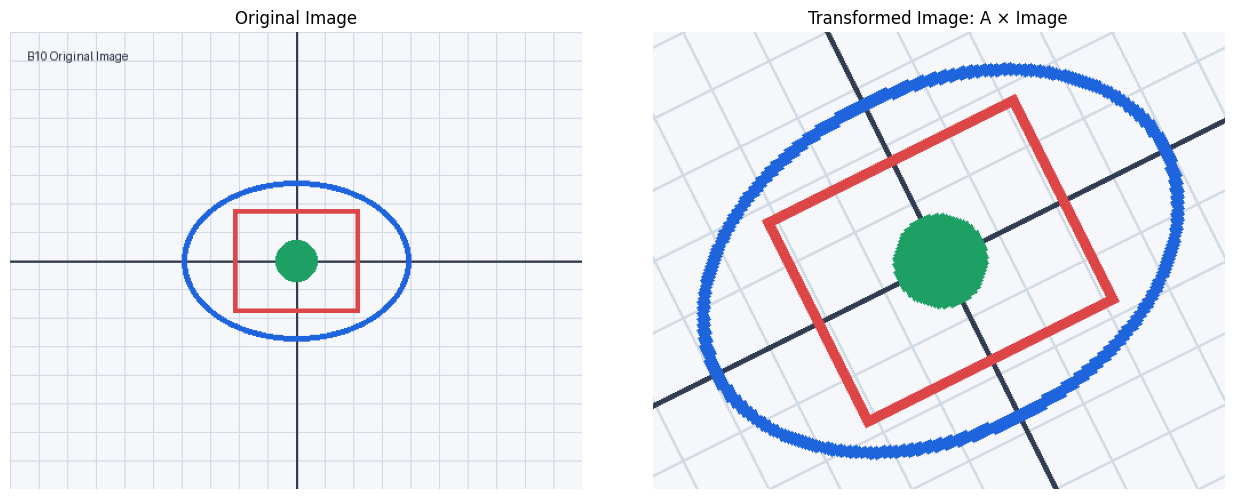

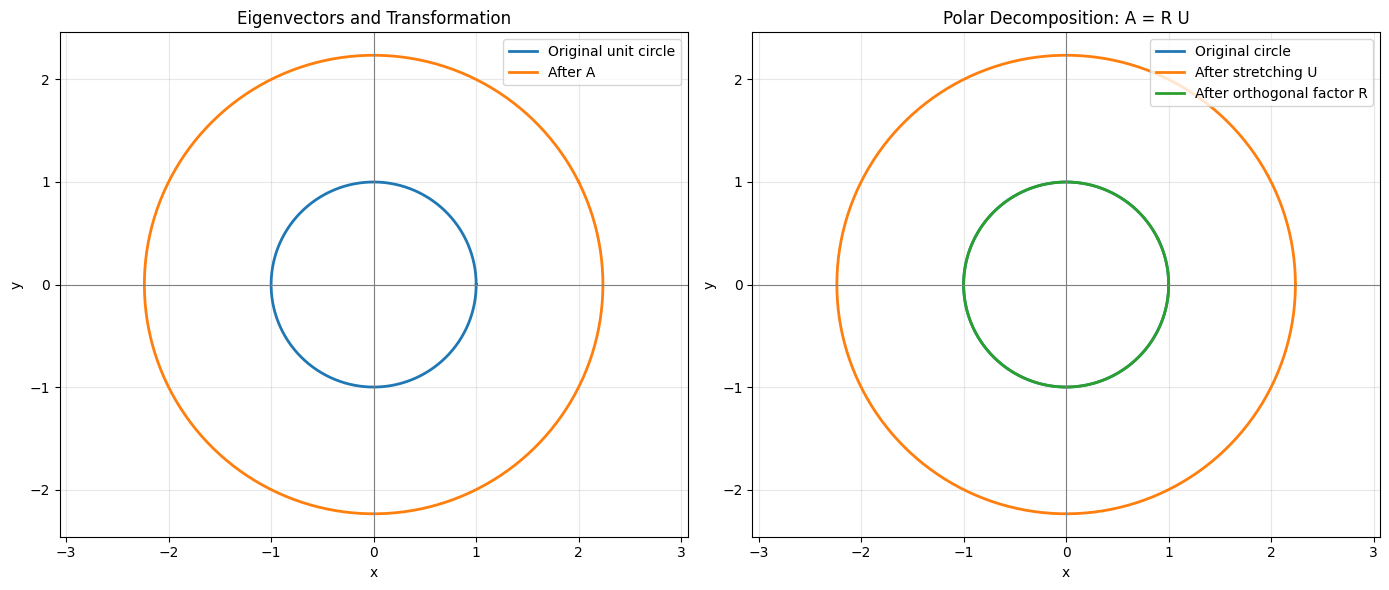

## Benchmark Test Results

,Eigenvalues,Real eigenvalues,Determinant,Invertible,Eigenpair test,Polar test,Singular values
Test case,,,,,,,
Identity,"1+0j, 1+0j",2,1.0,True,True,True,"1, 1"
Stretching,"2+0j, 0.5+0j",2,1.0,True,True,True,"2, 0.5"
90-degree rotation,"0+1j, 0-1j",0,1.0,True,True,True,"1, 1"
Shear,"1+0j, 1+0j",2,1.0,True,True,True,"1.62, 0.618"
Rotation + scaling,"0+2j, 0-2j",0,4.0,True,True,True,"2, 2"
Singular projection,"1+0j, 0+0j",2,0.0,False,True,True,"1, 0"



All benchmark tests passed!


# Final Project Summary


Project: Image Transformation Decomposer (B10)
Input matrix:
 [[ 2. -1.]
 [ 1.  2.]]
Characteristic polynomial: 5.0*(0.2*lambda**2 - 0.8*lambda + 1.0)

Eigenvalues:
lambda 1 = (2+1j)
lambda 2 = (2-1j)

Eigenvectors (columns of P):
 [[0.7071+0.j     0.7071-0.j    ]
 [0.    -0.7071j 0.    +0.7071j]]

Polar decomposition A = R U
R =
 [[ 0.8944 -0.4472]
 [ 0.4472  0.8944]]
U =
 [[2.2361 0.    ]
 [0.     2.2361]]

Eigen-decomposition available: True
Polar reconstruction error: 2.220446049250313e-16
Orthogonal factor type: Rotation

Transformed image saved as: B10_transformed_image.png

PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================
# B.TECH MATHEMATICS MINI PROJECT
# IMAGE TRANSFORMATION DECOMPOSER (B10)
# Eigenvalues, Eigenvectors, Rotation and Stretching
# Environment: Google Colab / Python
# Libraries: NumPy, SymPy, Matplotlib, Pandas, Pillow
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display, Markdown

np.set_printoptions(precision=4, suppress=True)

# ============================================================
# 1. USER INPUTS
# ============================================================

# Change these values to test different transformations.
A_INPUT = [
    [2.0, -1.0],
    [1.0,  2.0]
]

IMAGE_WIDTH = 500
IMAGE_HEIGHT = 400
USE_UPLOADED_IMAGE = False
TOLERANCE = 1e-8

A = np.array(A_INPUT, dtype=float)

if A.shape != (2, 2):
    raise ValueError("Enter a 2x2 transformation matrix.")

if not np.all(np.isfinite(A)):
    raise ValueError("Matrix entries must be finite.")

print("=" * 60)
print("IMAGE TRANSFORMATION DECOMPOSER (B10)")
print("=" * 60)
print("\nInput matrix A:\n", A)


# ============================================================
# 2. MATHEMATICAL ENGINE
# ============================================================

A_sym = sp.Matrix(A_INPUT)
lam = sp.symbols("lambda")

# Characteristic equation: det(A - lambda*I) = 0
characteristic_polynomial = sp.factor(
    (A_sym - lam * sp.eye(2)).det()
)

print("\n1. CHARACTERISTIC EQUATION")
print("det(A - lambda*I) =", characteristic_polynomial)
print("Solve the equation =", characteristic_polynomial, "= 0")

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("\n2. EIGENVALUES AND EIGENVECTORS")

for i, eigenvalue in enumerate(eigenvalues):
    vector = eigenvectors[:, i]
    residual = np.linalg.norm(A @ vector - eigenvalue * vector)

    print(f"\nEigenvalue {i+1}: {eigenvalue}")
    print(f"Eigenvector {i+1}: {vector}")
    print(f"Verification ||Av - lambda*v|| = {residual:.2e}")

    if residual < TOLERANCE:
        print("Eigenpair verified successfully.")

# Eigen-decomposition: A = P D P^(-1)
P = eigenvectors
D = np.diag(eigenvalues)

eigen_decomposition_available = (
    np.linalg.matrix_rank(P, tol=TOLERANCE) == 2
)

print("\n3. EIGEN-DECOMPOSITION")

if eigen_decomposition_available:
    A_reconstructed = P @ D @ np.linalg.inv(P)
    eigen_error = np.linalg.norm(A - A_reconstructed)

    print("A = P D P^(-1)")
    print("\nP =\n", P)
    print("\nD =\n", D)
    print("\nReconstruction error =", eigen_error)
else:
    eigen_error = None
    print("A complete eigen-decomposition is unavailable.")


# ============================================================
# 3. POLAR DECOMPOSITION: A = R U
# ============================================================

# SVD gives the orthogonal and stretching factors.
# R is orthogonal. U is symmetric positive semidefinite.
left_vectors, singular_values, right_vectors_T = np.linalg.svd(A)

R = left_vectors @ right_vectors_T
U = right_vectors_T.T @ np.diag(singular_values) @ right_vectors_T

polar_error = np.linalg.norm(A - R @ U)
det_A = np.linalg.det(A)

if np.linalg.det(R) > 0:
    factor_type = "Rotation"
else:
    factor_type = "Rotation combined with reflection"

print("\n4. POLAR DECOMPOSITION")
print("A = R U")
print("\nOrthogonal factor R:\n", R)
print("\nStretching factor U:\n", U)
print("\nOrthogonal factor type:", factor_type)
print("Singular values:", singular_values)
print("det(A) =", det_A)
print("Polar reconstruction error =", polar_error)

if abs(det_A) < TOLERANCE:
    print("Matrix is singular; U is not positive definite.")
else:
    print("Matrix is invertible; U is positive definite.")


# ============================================================
# 4. DISPLAY RESULTS IN TABLES
# ============================================================

display(Markdown("## Numerical Results"))

eigen_table = pd.DataFrame({
    "Eigenvalue": [str(v) for v in eigenvalues],
    "Eigenvector": [
        np.array2string(eigenvectors[:, i], precision=4)
        for i in range(2)
    ],
    "Magnitude": [float(abs(v)) for v in eigenvalues]
})

display(eigen_table)

decomposition_table = pd.DataFrame(
    np.round(A, 4),
    index=["Row 1", "Row 2"],
    columns=["Column 1", "Column 2"]
)

display(Markdown("### Input Transformation Matrix"))
display(decomposition_table)


# ============================================================
# 5. CREATE OR UPLOAD AN IMAGE
# ============================================================

if USE_UPLOADED_IMAGE:
    from google.colab import files

    uploaded = files.upload()

    if not uploaded:
        raise ValueError("Please upload an image.")

    filename = next(iter(uploaded))
    original_image = Image.open(filename).convert("RGB")
    original_image = original_image.resize(
        (IMAGE_WIDTH, IMAGE_HEIGHT)
    )

else:
    # Generate a sample image with grid, circles and a rectangle.
    original_image = Image.new(
        "RGB",
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        (245, 247, 250)
    )

    draw = ImageDraw.Draw(original_image)

    # Draw grid
    for x in range(0, IMAGE_WIDTH, 25):
        draw.line(
            [(x, 0), (x, IMAGE_HEIGHT)],
            fill=(210, 218, 228), width=1
        )

    for y in range(0, IMAGE_HEIGHT, 25):
        draw.line(
            [(0, y), (IMAGE_WIDTH, y)],
            fill=(210, 218, 228), width=1
        )

    cx, cy = IMAGE_WIDTH // 2, IMAGE_HEIGHT // 2

    # Coordinate axes
    draw.line(
        [(0, cy), (IMAGE_WIDTH, cy)],
        fill=(50, 60, 80), width=2
    )
    draw.line(
        [(cx, 0), (cx, IMAGE_HEIGHT)],
        fill=(50, 60, 80), width=2
    )

    # Shapes
    draw.ellipse(
        (cx-100, cy-70, cx+100, cy+70),
        outline=(30, 100, 220), width=5
    )

    draw.rectangle(
        (cx-55, cy-45, cx+55, cy+45),
        outline=(220, 70, 70), width=4
    )

    draw.ellipse(
        (cx-18, cy-18, cx+18, cy+18),
        fill=(30, 160, 100)
    )

    draw.text(
        (15, 15), "B10 Original Image",
        fill=(30, 40, 60)
    )

original_array = np.asarray(original_image)

plt.figure(figsize=(7, 5))
plt.imshow(original_array)
plt.title("Original Image")
plt.axis("off")
plt.show()


# ============================================================
# 6. TRANSFORM THE IMAGE USING MATRIX A
# ============================================================

def transform_image(image_array, matrix):
    """
    Apply a 2x2 Cartesian transformation matrix to an RGB image.

    Uses inverse mapping and nearest-neighbor sampling.
    The output canvas keeps the original dimensions.
    """

    height, width, channels = image_array.shape

    if channels != 3:
        raise ValueError("Expected an RGB image.")

    if abs(np.linalg.det(matrix)) < TOLERANCE:
        raise ValueError(
            "Image inverse mapping requires an invertible matrix. "
            "Choose a nonsingular transformation matrix."
        )

    # Destination coordinates centered on the image.
    x_dest, y_dest = np.meshgrid(
        np.arange(width) - (width - 1) / 2,
        (height - 1) / 2 - np.arange(height)
    )

    destination = np.vstack([
        x_dest.ravel(),
        y_dest.ravel()
    ])

    # Map destination pixels back to source pixels.
    source = np.linalg.inv(matrix) @ destination

    x_source = source[0] + (width - 1) / 2
    y_source = (height - 1) / 2 - source[1]

    x_source = np.rint(x_source).astype(int)
    y_source = np.rint(y_source).astype(int)

    # Fill outside pixels with a light background.
    output = np.full_like(image_array, 245)

    valid = (
        (x_source >= 0) & (x_source < width) &
        (y_source >= 0) & (y_source < height)
    )

    output_flat = output.reshape(-1, channels)
    input_flat = image_array.reshape(-1, channels)

    destination_indices = np.flatnonzero(valid)
    source_indices = y_source[valid] * width + x_source[valid]

    output_flat[destination_indices] = input_flat[source_indices]

    return output


transformed_array = None

if abs(det_A) >= TOLERANCE:
    transformed_array = transform_image(original_array, A)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].imshow(original_array)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(transformed_array)
    axes[1].set_title("Transformed Image: A × Image")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(
        "Image inverse mapping skipped because A is singular. "
        "Eigenvalue and geometric analyses are still available."
    )


# ============================================================
# 7. VISUALIZE EIGENVECTORS AND STRETCHING
# ============================================================

theta = np.linspace(0, 2*np.pi, 500)

# Points on a unit circle
circle = np.vstack([
    np.cos(theta),
    np.sin(theta)
])

transformed_circle = A @ circle
stretched_circle = U @ circle
orthogonal_circle = R @ circle

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Original circle and transformed circle
ax = axes[0]

ax.plot(
    circle[0], circle[1],
    label="Original unit circle", linewidth=2
)

ax.plot(
    transformed_circle[0], transformed_circle[1],
    label="After A", linewidth=2
)

for i, value in enumerate(eigenvalues):
    vector = eigenvectors[:, i]

    # Plot real eigenvector directions only.
    if np.all(np.abs(np.imag(vector)) < TOLERANCE):
        vector = np.real(vector)
        vector = vector / np.linalg.norm(vector)

        ax.quiver(
            0, 0, vector[0], vector[1],
            angles="xy", scale_units="xy", scale=1,
            color="crimson", width=0.008,
            label=f"Eigenvector {i+1}"
        )

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Eigenvectors and Transformation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
ax.axis("equal")
ax.legend()

# Chart 2: Polar decomposition
ax = axes[1]

ax.plot(
    circle[0], circle[1],
    label="Original circle", linewidth=2
)

ax.plot(
    stretched_circle[0], stretched_circle[1],
    label="After stretching U", linewidth=2
)

ax.plot(
    orthogonal_circle[0], orthogonal_circle[1],
    label="After orthogonal factor R", linewidth=2
)

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Polar Decomposition: A = R U")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
ax.axis("equal")
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. BENCHMARK DATASET AND AUTOMATED TESTS
# ============================================================

BENCHMARKS = {
    "Identity": np.array([[1, 0], [0, 1]], dtype=float),
    "Stretching": np.array([[2, 0], [0, 0.5]], dtype=float),
    "90-degree rotation": np.array([[0, -1], [1, 0]], dtype=float),
    "Shear": np.array([[1, 1], [0, 1]], dtype=float),
    "Rotation + scaling": np.array([[0, -2], [2, 0]], dtype=float),
    "Singular projection": np.array([[1, 0], [0, 0]], dtype=float)
}


def analyze_matrix(matrix):
    """Calculate eigenpair and polar reconstruction diagnostics."""

    values, vectors = np.linalg.eig(matrix)

    left, singular, right_t = np.linalg.svd(matrix)
    rotation = left @ right_t
    stretch = right_t.T @ np.diag(singular) @ right_t

    eigen_residual = max(
        np.linalg.norm(
            matrix @ vectors[:, i] - values[i] * vectors[:, i]
        )
        for i in range(2)
    )

    polar_residual = np.linalg.norm(
        matrix - rotation @ stretch
    )

    return {
        "Eigenvalues": ", ".join(
            f"{v.real:.3g}{v.imag:+.3g}j" for v in values
        ),
        "Real eigenvalues": int(
            np.count_nonzero(np.abs(values.imag) < TOLERANCE)
        ),
        "Determinant": round(float(np.linalg.det(matrix)), 4),
        "Invertible": abs(np.linalg.det(matrix)) > TOLERANCE,
        "Eigenpair test": eigen_residual < TOLERANCE,
        "Polar test": polar_residual < TOLERANCE,
        "Singular values": ", ".join(
            f"{v:.3g}" for v in singular
        )
    }


benchmark_rows = []

for name, matrix in BENCHMARKS.items():
    row = analyze_matrix(matrix)
    row["Test case"] = name
    benchmark_rows.append(row)

benchmark_table = pd.DataFrame(
    benchmark_rows
).set_index("Test case")

display(Markdown("## Benchmark Test Results"))
display(benchmark_table)

# Test numerical correctness
for name, matrix in BENCHMARKS.items():
    result = analyze_matrix(matrix)

    assert result["Eigenpair test"], (
        f"Eigenpair test failed for {name}"
    )

    assert result["Polar test"], (
        f"Polar reconstruction failed for {name}"
    )

print("\nAll benchmark tests passed!")


# ============================================================
# 9. FINAL PROJECT REPORT AND SAVE IMAGE
# ============================================================

display(Markdown("# Final Project Summary"))

print("\nProject: Image Transformation Decomposer (B10)")
print("Input matrix:\n", A)
print("Characteristic polynomial:", characteristic_polynomial)

print("\nEigenvalues:")
for i, value in enumerate(eigenvalues, start=1):
    print(f"lambda {i} =", value)

print("\nEigenvectors (columns of P):\n", eigenvectors)

print("\nPolar decomposition A = R U")
print("R =\n", R)
print("U =\n", U)

print("\nEigen-decomposition available:", eigen_decomposition_available)
print("Polar reconstruction error:", polar_error)
print("Orthogonal factor type:", factor_type)

if transformed_array is not None:
    output_filename = "B10_transformed_image.png"
    Image.fromarray(transformed_array).save(output_filename)
    print("\nTransformed image saved as:", output_filename)

    # Uncomment the following lines in Google Colab to download:
    # from google.colab import files
    # files.download(output_filename)

print("\nPROJECT COMPLETED SUCCESSFULLY!")